# TCGA TMB-Adjusted Disruption Heatmaps by Tissue and Gene

Median TMB-adjusted disruption across patients mapped to each AlphaGenome tissue. The notebook makes separate heatmaps for AlphaGenome-only and AlphaMissense-only scores.


In [1]:
import json
from pathlib import Path
from textwrap import fill

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns


In [2]:
# Paths and Settings
PROJECT_DIR = Path("..").resolve()

ALPHAGENOME_SCORES = PROJECT_DIR / "data/alphagenome_scores/patient_tissue_tracks_local/patient_tissue_track_scores.csv"
ALPHAGENOME_COMPLETION_LEDGER = ALPHAGENOME_SCORES.with_name("patient_tissue_track_scores.completed_patient_genes.tsv")
PATIENT_CANCER_MAP = PROJECT_DIR / "data/tcga_patient_cancer_map.json"
ALPHAMISSENSE_SCORES = PROJECT_DIR / "data/alphamissense_combined_gene_level_scores.tsv"
TISSUE_MAPPING = PROJECT_DIR / "metadata/cancer_tissue_alphagenome_tracks.tsv"
CANCER_GENES = PROJECT_DIR / "metadata/cancer_genes.tsv"
GENE_COORDS = PROJECT_DIR / "data/driver_genes_coords/Pancancer_1pc.tsv"
TMB_DIR = PROJECT_DIR / "data/TCGA/tcga_patient_variants_by_cancer"

OUTPUT_DIR = PROJECT_DIR / "results/tcga_combined_disruption_heatmaps"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MIN_PATIENTS_PER_CANCER_GENE = 1
TMB_PSEUDOCOUNT = 1e-6
N = 15  # Set to an integer to use the top N genes in GENE_COORDS.

SELECTED_ALPHAGENOME_MODALITIES = [
    "ATAC",
    "RNA_SEQ",
    "SPLICE_SITE_USAGE",
    "CHIP_TF"
]
CANCER_TYPE_ALPHAGENOME_MODALITIES = [
    *SELECTED_ALPHAGENOME_MODALITIES,
    "DNASE",
    "CHIP_HISTONE",
]

In [3]:
# Load cancer-to-tissue mapping
cancer_tissue_map = (
    pd.read_csv(TISSUE_MAPPING, sep="\t", usecols=["cancer_type", "tissue"])
    .dropna(subset=["cancer_type", "tissue"])
    .drop_duplicates(["cancer_type", "tissue"])
)
cancer_tissue_map.head()


,cancer_type,tissue
0,ACC,Adrenal Gland
27,BLCA,Bladder
46,BRCA,Breast
67,CESC,Cervix
81,CHOL,Biliary


In [4]:
# Load gene type labels
cancer_gene_type = pd.read_csv(CANCER_GENES, sep="\t")

def classify_gene_type(row):
    is_og = str(row["Is Oncogene"]).strip().lower() == "yes"
    is_tsg = str(row["Is Tumor Suppressor Gene"]).strip().lower() == "yes"
    if is_og and is_tsg:
        return "Unsure"
    if is_og:
        return "OG"
    if is_tsg:
        return "TSG"
    return "Unsure"

cancer_gene_type["type"] = cancer_gene_type.apply(classify_gene_type, axis=1)
gene_type_by_gene = cancer_gene_type.set_index("Hugo Symbol")["type"].to_dict()
gene_type_colors = {"OG": "#d62728", "TSG": "#1f77b4", "Unsure": "#d9d9d9"}
gene_type_labels = {"OG": "OG", "TSG": "TSG", "Unsure": "Uncertain"}
gene_type_order = {"OG": 0, "TSG": 1, "Unsure": 2}

In [5]:
# Select the top N genes in the order listed by GENE_COORDS.
gene_coords = pd.read_csv(GENE_COORDS, sep="\t", usecols=["gene", "length"]).drop_duplicates("gene")
if N is not None:
    gene_coords = gene_coords.head(N)
selected_genes = set(gene_coords["gene"])
print(f"Using {len(selected_genes):,} gene(s) from GENE_COORDS")

# Load gene lengths for length adjustment
gene_lengths = gene_coords.rename(columns={"length": "gene_length"})
gene_lengths["log10_gene_length"] = np.log10(gene_lengths["gene_length"])
gene_lengths.head()

Using 15 gene(s) from GENE_COORDS


,gene,gene_length,log10_gene_length
0,TP53,25760,4.410946
1,KRAS,45691,4.659831
2,PIK3CA,91980,4.963693
3,BRAF,205603,5.313029
4,APC,138742,5.142208


In [6]:
# Load AlphaGenome scores and distinguish true zeros from unavailable tracks.
# A completed patient-gene pair with an available modality is a true zero when
# its score is absent. Missing modalities for that cancer's mapped tissue remain absent.
available_modalities = (
    pd.read_csv(TISSUE_MAPPING, sep="\t", usecols=["cancer_type", "output_type"])
    .assign(output_type=lambda df: df["output_type"].str.removeprefix("OutputType."))
    .query("output_type in @CANCER_TYPE_ALPHAGENOME_MODALITIES")
    .drop_duplicates()
)

observed_ag_scores = pd.read_csv(ALPHAGENOME_SCORES)
observed_ag_scores = observed_ag_scores[observed_ag_scores["aggregation_type"].eq("L2_DIFF")].copy()
observed_ag_scores = observed_ag_scores[observed_ag_scores["scorer"].eq("PATIENT_SINGLE_TRACK_SCORER")].copy()
observed_ag_scores = observed_ag_scores[
    (observed_ag_scores["track_strand"].eq(observed_ag_scores["gene_strand"]))
    | (observed_ag_scores["track_strand"].eq("."))
]
observed_ag_scores = (
    observed_ag_scores
    .groupby(["patient_id", "cancer_type", "gene", "output_type"], as_index=False)
    .agg(score=("score", "median"))
    .merge(available_modalities, on=["cancer_type", "output_type"], how="inner")
)
observed_ag_scores = observed_ag_scores[observed_ag_scores["gene"].isin(selected_genes)].copy()

patient_cancer = (
    pd.Series(json.loads(PATIENT_CANCER_MAP.read_text()), name="cancer_type")
    .rename_axis("patient_id")
    .reset_index()
)
completed_zero_scores = (
    pd.read_csv(ALPHAGENOME_COMPLETION_LEDGER, sep="\t", dtype=str)
    .merge(patient_cancer, on="patient_id", how="inner")
    .merge(available_modalities, on="cancer_type", how="inner")
)
completed_zero_scores["score"] = 0.0
completed_zero_scores = completed_zero_scores[completed_zero_scores["gene"].isin(selected_genes)].copy()

# Keep observed values, including actual observed zeros, ahead of ledger-imputed zeros.
ag_scores = (
    pd.concat([observed_ag_scores, completed_zero_scores], ignore_index=True)
    .drop_duplicates(["patient_id", "cancer_type", "gene", "output_type"], keep="first")
)
print(f"Observed AlphaGenome scores: {len(observed_ag_scores):,}")
print(f"Completed-pair zero scores added: {len(ag_scores) - len(observed_ag_scores):,}")
ag_scores.head()

Observed AlphaGenome scores: 669,282
Completed-pair zero scores added: 14,223


,patient_id,cancer_type,gene,output_type,score
0,TCGA-02-0016,GBM,APC,CHIP_HISTONE,16.000459
1,TCGA-02-0016,GBM,APC,DNASE,0.241892
2,TCGA-02-0016,GBM,APC,RNA_SEQ,0.745887
3,TCGA-02-0016,GBM,APC,SPLICE_SITE_USAGE,0.008194
4,TCGA-02-0016,GBM,ARID1A,CHIP_HISTONE,20.070642


In [7]:
# Load Alphamissense Scores
gene_list = ag_scores["gene"].unique()
print(f"Number of unique genes in AlphaGenome scores: {len(gene_list)}")
alphamissense_scores = pd.read_csv(
    ALPHAMISSENSE_SCORES,
    sep="\t",
    usecols=["bcr_patient_barcode", "cancer_type", "gene", "combined_pathogenicity_burden"],
).rename(columns={
    "bcr_patient_barcode": "patient_id",
    "combined_pathogenicity_burden": "score",
})
alphamissense_scores = alphamissense_scores[alphamissense_scores["gene"].isin(gene_list)]
alphamissense_scores = alphamissense_scores.dropna(subset=["score"]).copy()
alphamissense_scores["output_type"] = "ALPHAMISSENSE"
alphamissense_scores.head()

Number of unique genes in AlphaGenome scores: 15


,patient_id,cancer_type,gene,score,output_type
5,TCGA-02-0016,GBM,ARID1A,0.2386,ALPHAMISSENSE
122,TCGA-02-0026,GBM,IDH1,0.9920,ALPHAMISSENSE
168,TCGA-02-0026,GBM,TP53,0.9987,ALPHAMISSENSE
214,TCGA-02-0033,GBM,PIK3CA,0.9409,ALPHAMISSENSE
225,TCGA-02-0033,GBM,TP53,0.9963,ALPHAMISSENSE


In [8]:
# Combine Scores
ag_score_df = ag_scores[["patient_id", "cancer_type", "gene", "output_type", "score"]].copy()
ag_score_df["score_source"] = "AlphaGenome"
ag_score_df["normalized_score"] = ag_score_df["score"]

am_score_df = alphamissense_scores[["patient_id", "cancer_type", "gene", "output_type", "score"]].copy()
am_score_df["score_source"] = "AlphaMissense"
# Normalize AlphaMissense scores across all patient-gene pairs.
alphamissense_std = am_score_df["score"].std(ddof=0)
am_score_df["normalized_score"] = (
    (am_score_df["score"] - am_score_df["score"].mean()) / alphamissense_std
    if alphamissense_std else 0
)

score_df = pd.concat([ag_score_df, am_score_df], ignore_index=True)

In [9]:
# Load TMB values
def load_tmb_values():
    tmb_rows = []
    skipped_files = []
    for path in sorted(TMB_DIR.glob("*_tmb.tsv")):
        cancer_type = path.name.removesuffix("_tmb.tsv")
        try:
            tmb = pd.read_csv(path, sep="\t", dtype={"bcr_patient_barcode": str})
        except pd.errors.EmptyDataError:
            skipped_files.append(path.name)
            continue
        tmb = tmb.rename(columns={"bcr_patient_barcode": "patient_id"})
        tmb["total_mutations"] = pd.to_numeric(tmb["total_mutations"], errors="coerce")
        tmb = tmb.dropna(subset=["patient_id", "total_mutations"])
        tmb["cancer_type"] = cancer_type
        tmb["tmb"] = np.log1p(tmb["total_mutations"].astype(float))
        tmb_rows.append(tmb[["patient_id", "cancer_type", "tmb", "total_mutations"]])
    if skipped_files:
        print(f"Skipped {len(skipped_files)} empty TMB file(s): {skipped_files}")
    return pd.concat(tmb_rows, ignore_index=True).drop_duplicates(["patient_id", "cancer_type"])

tmb_df = load_tmb_values()
tmb_df.head()

Skipped 1 empty TMB file(s): ['LAML_tmb.tsv']


,patient_id,cancer_type,tmb,total_mutations
0,TCGA-OR-A5J1,ACC,9.897671,19883
1,TCGA-OR-A5J2,ACC,10.454264,34691
2,TCGA-OR-A5J3,ACC,10.629876,41351
3,TCGA-OR-A5J4,ACC,10.627334,41246
4,TCGA-OR-A5J5,ACC,12.375292,236875


In [10]:
# Build TMB- and gene-length-adjusted patient-gene and tissue-gene summaries
def add_length_adjusted_residuals(df, value_col, group_cols, output_col):
    df = df.merge(gene_lengths, on="gene", how="left")
    df[output_col] = np.nan
    for _, group_idx in df.groupby(group_cols).groups.items():
        valid = df.loc[group_idx, value_col].notna() & df.loc[group_idx, "log10_gene_length"].notna()
        valid_idx = df.loc[group_idx].index[valid]
        if len(valid_idx) >= 2 and df.loc[valid_idx, "log10_gene_length"].nunique() >= 2:
            slope, intercept = np.polyfit(
                df.loc[valid_idx, "log10_gene_length"],
                df.loc[valid_idx, value_col],
                deg=1,
            )
            expected = slope * df.loc[valid_idx, "log10_gene_length"] + intercept
            df.loc[valid_idx, output_col] = df.loc[valid_idx, value_col] - expected
        elif len(valid_idx) > 0:
            df.loc[valid_idx, output_col] = df.loc[valid_idx, value_col] - df.loc[valid_idx, value_col].mean()
    return df


# AlphaGenome preprocessing shared by every AlphaGenome plot.
# Track-level scores were median-aggregated within each patient-gene-modality in cell 6.
alphagenome_all_modality_scores = (
    score_df[score_df["score_source"].eq("AlphaGenome")]
    .merge(cancer_tissue_map, on="cancer_type", how="left")
    .merge(
        tmb_df[["patient_id", "cancer_type", "tmb", "total_mutations"]],
        on=["patient_id", "cancer_type"],
        how="left",
    )
    .dropna(subset=["tissue", "tmb", "score"])
)
alphagenome_all_modality_scores["tmb_adjusted_score"] = (
    alphagenome_all_modality_scores["score"] / (alphagenome_all_modality_scores["tmb"] + TMB_PSEUDOCOUNT)
)
alphagenome_all_modality_scores = add_length_adjusted_residuals(
    alphagenome_all_modality_scores,
    value_col="tmb_adjusted_score",
    group_cols=["patient_id", "tissue", "output_type"],
    output_col="length_tmb_adjusted_score",
).dropna(subset=["length_tmb_adjusted_score"])
alphagenome_all_modality_scores.head()

,patient_id,cancer_type,gene,output_type,score,score_source,normalized_score,tissue,tmb,total_mutations,tmb_adjusted_score,gene_length,log10_gene_length,length_tmb_adjusted_score
0,TCGA-02-0016,GBM,APC,CHIP_HISTONE,16.000459,AlphaGenome,16.000459,CNS,10.24021,28006,1.562513,138742,5.142208,-30.861489
1,TCGA-02-0016,GBM,APC,DNASE,0.241892,AlphaGenome,0.241892,CNS,10.24021,28006,0.023622,138742,5.142208,-0.060624
2,TCGA-02-0016,GBM,APC,RNA_SEQ,0.745887,AlphaGenome,0.745887,CNS,10.24021,28006,0.072839,138742,5.142208,-0.069793
3,TCGA-02-0016,GBM,APC,SPLICE_SITE_USAGE,0.008194,AlphaGenome,0.008194,CNS,10.24021,28006,0.000800,138742,5.142208,-0.003351
4,TCGA-02-0016,GBM,ARID1A,CHIP_HISTONE,20.070642,AlphaGenome,20.070642,CNS,10.24021,28006,1.959983,88869,4.948750,-26.807635


In [11]:
def z_score_normalize(scores):
    return (scores - scores.mean()) / (scores.std() + 1e-6)

alphagenome_all_modality_scores["normalized_score"] = (
    alphagenome_all_modality_scores
    .groupby("output_type")["length_tmb_adjusted_score"]
    .transform(z_score_normalize)
)
alphagenome_all_modality_scores["preprocessed"] = True
alphagenome_modality_scores = alphagenome_all_modality_scores[
    alphagenome_all_modality_scores["output_type"].isin(SELECTED_ALPHAGENOME_MODALITIES)
].copy()
alphagenome_modality_scores.head()

,patient_id,cancer_type,gene,output_type,score,score_source,normalized_score,tissue,tmb,total_mutations,tmb_adjusted_score,gene_length,log10_gene_length,length_tmb_adjusted_score,preprocessed
2,TCGA-02-0016,GBM,APC,RNA_SEQ,0.745887,AlphaGenome,-0.268421,CNS,10.24021,28006,0.072839,138742,5.142208,-0.069793,True
3,TCGA-02-0016,GBM,APC,SPLICE_SITE_USAGE,0.008194,AlphaGenome,-0.377846,CNS,10.24021,28006,0.000800,138742,5.142208,-0.003351,True
6,TCGA-02-0016,GBM,ARID1A,RNA_SEQ,0.585543,AlphaGenome,-0.294705,CNS,10.24021,28006,0.057181,88869,4.948750,-0.076628,True
7,TCGA-02-0016,GBM,ARID1A,SPLICE_SITE_USAGE,0.010155,AlphaGenome,-0.284491,CNS,10.24021,28006,0.000992,88869,4.948750,-0.002523,True
10,TCGA-02-0016,GBM,BRAF,RNA_SEQ,1.635990,AlphaGenome,0.035911,CNS,10.24021,28006,0.159761,205603,5.313029,0.009337,True


In [12]:
alphagenome_patient_gene_scores = (
    alphagenome_modality_scores
    .groupby(["patient_id", "cancer_type", "gene", "tissue", "tmb", "total_mutations"], as_index=False)
    .agg(
        disruption=("normalized_score", "max"),
        n_modalities=("output_type", "nunique"),
        preprocessed=("preprocessed", "all"),
    )
)
alphagenome_patient_gene_scores.head()

,patient_id,cancer_type,gene,tissue,tmb,total_mutations,disruption,n_modalities,preprocessed
0,TCGA-02-0016,GBM,APC,CNS,10.24021,28006,-0.268421,2,True
1,TCGA-02-0016,GBM,ARID1A,CNS,10.24021,28006,-0.284491,2,True
2,TCGA-02-0016,GBM,BRAF,CNS,10.24021,28006,0.035911,2,True
3,TCGA-02-0016,GBM,CDKN2A,CNS,10.24021,28006,-0.147289,2,True
4,TCGA-02-0016,GBM,CSMD3,CNS,10.24021,28006,-0.574688,2,True


## AlphaGenome-derived disruption

In [13]:
def summarize_disruption(input_df, label):
    is_preprocessed = input_df.get("preprocessed", pd.Series(False, index=input_df.index)).all()
    if {"disruption", "n_modalities"}.issubset(input_df.columns):
        patient_gene = input_df.copy()
    elif is_preprocessed:
        patient_gene = (
            input_df
            .groupby(["patient_id", "cancer_type", "gene", "tissue", "tmb", "total_mutations"], as_index=False)
            .agg(
                disruption=("normalized_score", "max"),
                n_modalities=("output_type", "nunique"),
            )
        )
    else:
        patient_gene = (
            input_df
            .groupby(["patient_id", "cancer_type", "gene"], as_index=False)
            .agg(
                disruption=("normalized_score", "max"),
                n_modalities=("output_type", "nunique"),
            )
        )
    if is_preprocessed:
        patient_gene["tmb_adjusted_disruption"] = patient_gene["disruption"]
    else:
        patient_gene = patient_gene.merge(cancer_tissue_map, on="cancer_type", how="left")
        patient_gene = patient_gene.merge(
            tmb_df[["patient_id", "cancer_type", "tmb", "total_mutations"]],
            on=["patient_id", "cancer_type"],
            how="left",
        )
        patient_gene["tmb_adjusted_disruption"] = patient_gene["disruption"] / (patient_gene["tmb"] + TMB_PSEUDOCOUNT)
    patient_gene = patient_gene.dropna(subset=["tissue", "tmb_adjusted_disruption"])

    tissue_gene = (
        patient_gene
        .groupby(["tissue", "gene"], as_index=False)
        .agg(
            median_disruption=("disruption", "median"),
            median_tmb_adjusted_disruption=("tmb_adjusted_disruption", "median"),
            n_patients=("patient_id", "nunique"),
            n_cancer_types=("cancer_type", "nunique"),
            mean_n_modalities=("n_modalities", "mean"),
            median_tmb=("tmb", "median"),
        )
    )
    if is_preprocessed:
        tissue_gene["length_tmb_adjusted_disruption"] = tissue_gene["median_tmb_adjusted_disruption"]
    else:
        tissue_gene = add_length_adjusted_residuals(
            tissue_gene,
            value_col="median_tmb_adjusted_disruption",
            group_cols=["tissue"],
            output_col="length_tmb_adjusted_disruption",
        )
    tissue_gene = tissue_gene[tissue_gene["n_patients"].ge(MIN_PATIENTS_PER_CANCER_GENE)].copy()
    tissue_gene["score_set"] = label
    return patient_gene, tissue_gene


In [14]:
alphagenome_patient_gene_disruption, alphagenome_tissue_gene_disruption = summarize_disruption(
    alphagenome_patient_gene_scores,
    "alphagenome",
)
alphagenome_tissue_gene_disruption.head()

,tissue,gene,median_disruption,median_tmb_adjusted_disruption,n_patients,n_cancer_types,mean_n_modalities,median_tmb,length_tmb_adjusted_disruption,score_set
0,Adrenal Gland,APC,-0.352040,-0.352040,239,2,4.0,9.70345,-0.352040,alphagenome
1,Adrenal Gland,ARID1A,1.529963,1.529963,239,2,4.0,9.70345,1.529963,alphagenome
2,Adrenal Gland,BRAF,-0.195617,-0.195617,239,2,4.0,9.70345,-0.195617,alphagenome
3,Adrenal Gland,CDKN2A,-0.127820,-0.127820,239,2,4.0,9.70345,-0.127820,alphagenome
4,Adrenal Gland,CSMD3,-0.037711,-0.037711,239,2,4.0,9.70345,-0.037711,alphagenome


In [15]:
alphagenome_patient_gene_scores.head()

,patient_id,cancer_type,gene,tissue,tmb,total_mutations,disruption,n_modalities,preprocessed
0,TCGA-02-0016,GBM,APC,CNS,10.24021,28006,-0.268421,2,True
1,TCGA-02-0016,GBM,ARID1A,CNS,10.24021,28006,-0.284491,2,True
2,TCGA-02-0016,GBM,BRAF,CNS,10.24021,28006,0.035911,2,True
3,TCGA-02-0016,GBM,CDKN2A,CNS,10.24021,28006,-0.147289,2,True
4,TCGA-02-0016,GBM,CSMD3,CNS,10.24021,28006,-0.574688,2,True


In [16]:
heatmap_df = alphagenome_tissue_gene_disruption.pivot_table(
    index="tissue",
    columns="gene",
    values="length_tmb_adjusted_disruption",
)
tissue_order = sorted(heatmap_df.index)
gene_order = sorted(heatmap_df.columns)
heatmap_df = heatmap_df.loc[tissue_order, gene_order]
# Normalize the heatmap such that for each tissue, genes are ranked by percentile
heatmap_df = heatmap_df.rank(pct=True, axis=1)
print(heatmap_df.shape)
heatmap_df.head()

(25, 15)


gene,APC,ARID1A,BRAF,CDKN2A,CSMD3,CTNNB1,IDH1,KMT2C,KMT2D,KRAS,LRP1B,NRAS,PIK3CA,PTEN,TP53
tissue,,,,,,,,,,,,,,,
Adrenal Gland,0.066667,0.933333,0.133333,0.200000,0.266667,0.400000,0.666667,1.000000,0.466667,0.866667,0.600000,0.333333,0.733333,0.533333,0.800000
Biliary,0.066667,0.866667,0.466667,0.266667,0.200000,0.333333,1.000000,0.933333,0.800000,0.533333,0.600000,0.133333,0.400000,0.733333,0.666667
Bladder,0.066667,0.933333,0.533333,0.200000,0.400000,1.000000,0.733333,0.866667,0.800000,0.266667,0.333333,0.133333,0.466667,0.666667,0.600000
Breast,0.066667,0.733333,0.533333,0.133333,0.333333,0.400000,0.933333,1.000000,0.866667,0.600000,0.466667,0.200000,0.266667,0.800000,0.666667
CNS,0.200000,0.800000,0.533333,0.133333,0.400000,0.666667,0.733333,0.933333,1.000000,0.600000,0.333333,0.266667,0.066667,0.866667,0.466667


/Users/an36943/PhD/Projects/cancer_non_coding/results/tcga_combined_disruption_heatmaps/tcga_alphagenome_median_length_tmb_adjusted_disruption_by_tissue_heatmap.png


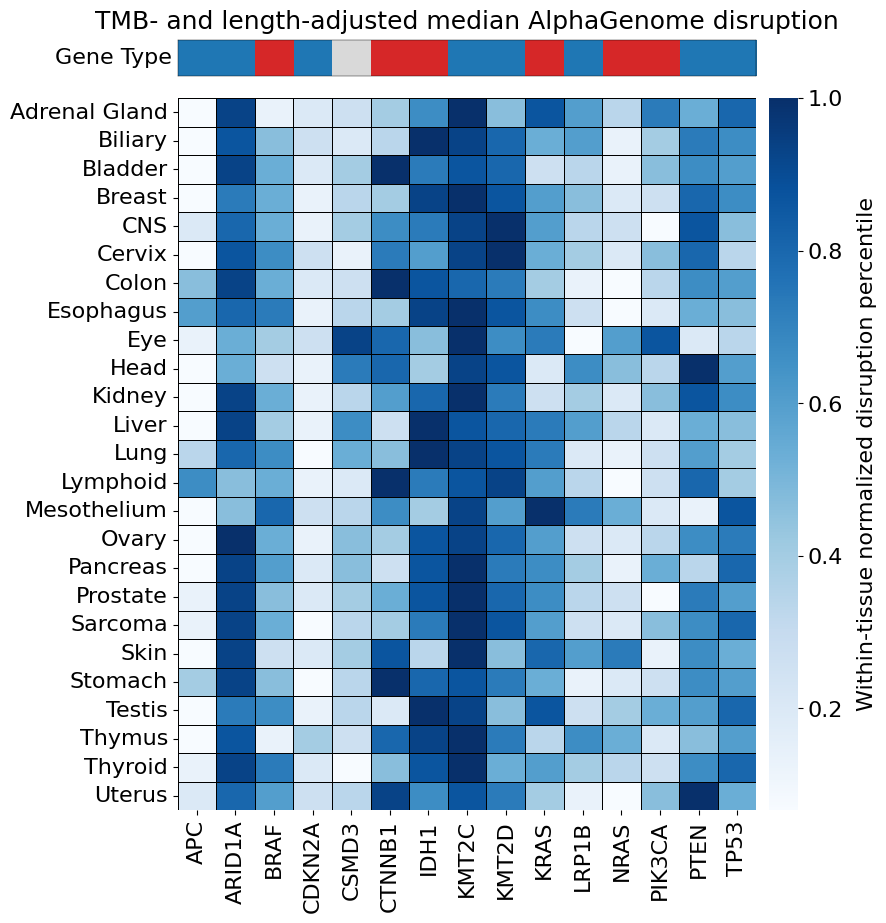

In [17]:
def order_heatmap_genes(heatmap_df):
    return sorted(heatmap_df.columns)


def order_heatmap_tissues(heatmap_df):
    return sorted(heatmap_df.index)


def plot_tissue_gene_heatmap(heatmap_df, title, output_plot, tissue_order=None, gene_order=None):
    tissue_order = tissue_order or order_heatmap_tissues(heatmap_df)
    gene_order = gene_order or order_heatmap_genes(heatmap_df)
    heatmap_df = heatmap_df.loc[tissue_order, gene_order]
    gene_types = [gene_type_by_gene.get(gene, "Unsure") for gene in heatmap_df.columns]
    type_colors = np.array([[mcolors.to_rgba(gene_type_colors[gene_type]) for gene_type in gene_types]])
    fig_width = max(8, 0.4 * heatmap_df.shape[1])
    fig_height = max(6, 0.4 * heatmap_df.shape[0])
    fig, axes = plt.subplots(
        2,
        2,
        figsize=(fig_width, fig_height),
        gridspec_kw={"height_ratios": [0.25, 5], "width_ratios": [20, 1], "hspace": 0.06, "wspace": 0.04},
    )
    type_ax, type_legend_ax = axes[0]
    ax, cbar_ax = axes[1]
    type_legend_ax.set_axis_off()

    type_ax.imshow(type_colors, aspect="auto", extent=(0, heatmap_df.shape[1], 0, 1))
    type_ax.set_xlim(0, heatmap_df.shape[1])
    type_ax.set_xticks([])
    type_ax.set_yticks([])
    type_ax.set_ylabel("Gene Type", fontsize=16, rotation=0, ha="right", va="center")
    for spine in type_ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(0.3)

    present_gene_types = [gene_type for gene_type in gene_type_colors if gene_type in set(gene_types)]
    type_handles = [
        mpatches.Patch(color=gene_type_colors[gene_type], label=gene_type_labels[gene_type])
        for gene_type in ["OG", "TSG"]
    ]

    sns.heatmap(
        heatmap_df,
        ax=ax,
        cmap="Blues",
        linewidths=0.5,
        linecolor="black",
        cbar_ax=cbar_ax,
        cbar_kws={"label": "Within-tissue normalized disruption percentile"},
    )
    ax.set_title(title, fontsize=18, pad=50)
    ax.set_xlabel("", fontsize=16)
    ax.set_ylabel("", fontsize=16)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center", fontsize=16)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=16)

    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=16)
    cbar.set_label("Within-tissue normalized disruption percentile", fontsize=16, labelpad=10)
    # if type_handles:
    #     type_legend_ax.legend(handles=type_handles, loc="upper right", frameon=False, fontsize=16, bbox_to_anchor=(2.5, 2.5))

    fig.savefig(output_plot, dpi=300, bbox_inches="tight")
    return fig


alphagenome_plot_tissue_order = order_heatmap_tissues(heatmap_df)
alphagenome_plot_gene_order = order_heatmap_genes(heatmap_df)

output_plot = OUTPUT_DIR / "tcga_alphagenome_median_length_tmb_adjusted_disruption_by_tissue_heatmap.png"
fig = plot_tissue_gene_heatmap(
    heatmap_df,
    f"TMB- and length-adjusted median AlphaGenome disruption",
    output_plot,
    tissue_order=alphagenome_plot_tissue_order,
    gene_order=alphagenome_plot_gene_order,
)
print(output_plot)

### AlphaGenome tissues with complete modality coverage


Keeping 13 tissue(s) with all 4 selected AlphaGenome modalities.
['ATAC', 'RNA_SEQ', 'SPLICE_SITE_USAGE', 'CHIP_TF']
['Adrenal Gland', 'Breast', 'Colon', 'Esophagus', 'Liver', 'Lung', 'Lymphoid', 'Ovary', 'Pancreas', 'Sarcoma', 'Stomach', 'Thyroid', 'Uterus']
(13, 15)
/Users/an36943/PhD/Projects/cancer_non_coding/results/tcga_combined_disruption_heatmaps/tcga_alphagenome_selected_complete_modalities_median_length_tmb_adjusted_disruption_by_tissue_heatmap.png


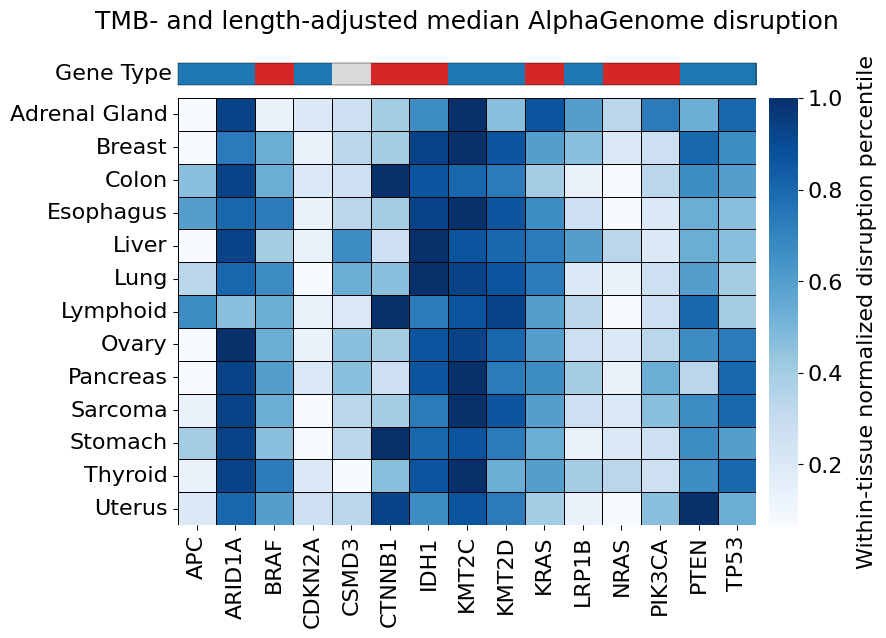

In [18]:
selected_alphagenome_scores = score_df[
    score_df["score_source"].eq("AlphaGenome")
    & score_df["output_type"].isin(SELECTED_ALPHAGENOME_MODALITIES)
].copy()

alphagenome_scores_with_tissue = (
    selected_alphagenome_scores
    .merge(cancer_tissue_map, on="cancer_type", how="left")
    .dropna(subset=["tissue", "output_type"])
)

tissue_modality_counts = alphagenome_scores_with_tissue.groupby("tissue")["output_type"].nunique()
complete_modality_tissues = tissue_modality_counts[
    tissue_modality_counts.eq(len(SELECTED_ALPHAGENOME_MODALITIES))
].index

alphagenome_complete_tissue_gene_disruption = alphagenome_tissue_gene_disruption[
    alphagenome_tissue_gene_disruption["tissue"].isin(complete_modality_tissues)
].copy()

complete_heatmap_df = alphagenome_complete_tissue_gene_disruption.pivot_table(
    index="tissue",
    columns="gene",
    values="length_tmb_adjusted_disruption",
)
complete_heatmap_df = complete_heatmap_df.loc[sorted(complete_heatmap_df.index), sorted(complete_heatmap_df.columns)]
# Normalize the heatmap such that for each tissue, genes are ranked by percentile
complete_heatmap_df = complete_heatmap_df.rank(pct=True, axis=1)
print(
    f"Keeping {len(complete_modality_tissues)} tissue(s) with all "
    f"{len(SELECTED_ALPHAGENOME_MODALITIES)} selected AlphaGenome modalities."
)
print(SELECTED_ALPHAGENOME_MODALITIES)
print(sorted(complete_modality_tissues))
print(complete_heatmap_df.shape)

output_plot = OUTPUT_DIR / "tcga_alphagenome_selected_complete_modalities_median_length_tmb_adjusted_disruption_by_tissue_heatmap.png"
fig = plot_tissue_gene_heatmap(
    complete_heatmap_df,
    "TMB- and length-adjusted median AlphaGenome disruption",
    output_plot,
)
print(output_plot)

### Dominant AlphaGenome modality by tissue and gene

/Users/an36943/PhD/Projects/cancer_non_coding/results/tcga_combined_disruption_heatmaps/tcga_alphagenome_complete_modalities_dominant_modality_by_tissue_gene_heatmap.png


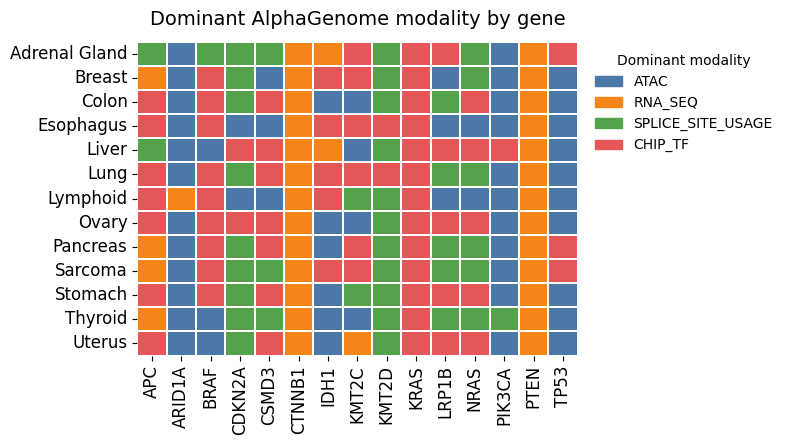

In [19]:
dominant_complete_modality_tissues = (
    score_df[
        score_df["score_source"].eq("AlphaGenome")
        & score_df["output_type"].isin(SELECTED_ALPHAGENOME_MODALITIES)
    ]
    .merge(cancer_tissue_map, on="cancer_type", how="left")
    .dropna(subset=["tissue", "output_type"])
    .groupby("tissue")["output_type"].nunique()
    .loc[lambda counts: counts.eq(len(SELECTED_ALPHAGENOME_MODALITIES))]
    .index
)
complete_alphagenome_plot_df = heatmap_df.loc[
    heatmap_df.index.intersection(dominant_complete_modality_tissues)
]
complete_alphagenome_plot_tissue_order = order_heatmap_tissues(complete_alphagenome_plot_df)
complete_alphagenome_plot_gene_order = order_heatmap_genes(complete_alphagenome_plot_df)

modality_tissue_gene_scores = []
for modality in SELECTED_ALPHAGENOME_MODALITIES:
    _, modality_tissue_gene_disruption = summarize_disruption(
        alphagenome_modality_scores[alphagenome_modality_scores["output_type"].eq(modality)],
        f"alphagenome_{modality.lower()}",
    )
    modality_tissue_gene_disruption["output_type"] = modality
    modality_tissue_gene_scores.append(
        modality_tissue_gene_disruption[
            ["tissue", "gene", "output_type", "length_tmb_adjusted_disruption"]
        ]
    )

modality_score_df = (
    pd.concat(modality_tissue_gene_scores, ignore_index=True)
    .loc[lambda scores: scores["tissue"].isin(dominant_complete_modality_tissues)]
    .pivot_table(
    index=["tissue", "gene"],
    columns="output_type",
    values="length_tmb_adjusted_disruption",
    )
)
dominant_modality_df = modality_score_df.apply(
    lambda scores: scores.idxmax() if scores.notna().any() else np.nan,
    axis=1,
).unstack("gene").reindex(
    index=complete_alphagenome_plot_tissue_order,
    columns=complete_alphagenome_plot_gene_order,
)

modality_colors = {
    "ATAC": "#4C78A8",
    "RNA_SEQ": "#F58518",
    "SPLICE_SITE_USAGE": "#54A24B",
    "CHIP_TF": "#E45756",
}
modality_to_code = {modality: i for i, modality in enumerate(SELECTED_ALPHAGENOME_MODALITIES)}
dominant_modality_codes = dominant_modality_df.apply(lambda column: column.map(modality_to_code))

fig, ax = plt.subplots(
    figsize=(max(8, 0.35 * dominant_modality_df.shape[1]), max(4, 0.35 * dominant_modality_df.shape[0]))
)
sns.heatmap(
    dominant_modality_codes,
    mask=dominant_modality_codes.isna(),
    cmap=mcolors.ListedColormap([modality_colors[modality] for modality in SELECTED_ALPHAGENOME_MODALITIES]),
    vmin=0,
    vmax=len(SELECTED_ALPHAGENOME_MODALITIES) - 1,
    cbar=False,
    linewidths=0.25,
    linecolor="white",
    ax=ax,
)
ax.set_title("Dominant AlphaGenome modality by gene", fontsize=14, pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=12)
ax.legend(
    handles=[mpatches.Patch(color=modality_colors[modality], label=modality) for modality in SELECTED_ALPHAGENOME_MODALITIES],
    title="Dominant modality",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    frameon=False,
)
fig.tight_layout()
output_plot = OUTPUT_DIR / "tcga_alphagenome_complete_modalities_dominant_modality_by_tissue_gene_heatmap.png"
fig.savefig(output_plot, dpi=300, bbox_inches="tight")
print(output_plot)

## AlphaMissense-derived disruption

In [20]:
alphamissense_patient_gene_disruption, alphamissense_tissue_gene_disruption = summarize_disruption(
    score_df[score_df["score_source"].eq("AlphaMissense")],
    "alphamissense",
)
alphamissense_tissue_gene_disruption.head()

,tissue,gene,median_disruption,median_tmb_adjusted_disruption,n_patients,n_cancer_types,mean_n_modalities,median_tmb,gene_length,log10_gene_length,length_tmb_adjusted_disruption,score_set
0,Adrenal Gland,APC,-1.136180,-0.104719,4,2,1.0,11.497793,138742,5.142208,-0.065291,alphamissense
1,Adrenal Gland,ARID1A,-0.635631,-0.062577,2,2,1.0,10.319669,88869,4.948750,-0.029874,alphamissense
2,Adrenal Gland,BRAF,0.253193,0.024464,2,2,1.0,10.424396,205603,5.313029,0.069831,alphamissense
3,Adrenal Gland,CDKN2A,-0.663936,-0.051717,3,2,1.0,12.526506,27550,4.440122,-0.036695,alphamissense
4,Adrenal Gland,CSMD3,-0.537982,-0.046369,4,1,1.0,12.092372,1214012,6.084223,0.025807,alphamissense


In [21]:
heatmap_df = alphamissense_tissue_gene_disruption.pivot_table(
    index="tissue",
    columns="gene",
    values="length_tmb_adjusted_disruption",
)
tissue_order = sorted(heatmap_df.index)
gene_order = sorted(heatmap_df.columns)
heatmap_df = heatmap_df.loc[tissue_order, gene_order]

# Normalize the heatmap such that for each tissue, genes are ranked by percentile
heatmap_df = heatmap_df.rank(pct=True, axis=1)
print(heatmap_df.shape)
heatmap_df.head()

(25, 15)


gene,APC,ARID1A,BRAF,CDKN2A,CSMD3,CTNNB1,IDH1,KMT2C,KMT2D,KRAS,LRP1B,NRAS,PIK3CA,PTEN,TP53
tissue,,,,,,,,,,,,,,,
Adrenal Gland,0.153846,0.307692,1.0,0.230769,0.692308,0.923077,0.846154,0.538462,0.076923,NaN,0.461538,0.615385,0.384615,NaN,0.769231
Biliary,NaN,NaN,1.0,0.083333,0.916667,NaN,0.666667,0.500000,0.166667,0.833333,0.250000,0.583333,0.416667,0.333333,0.750000
Bladder,0.066667,0.133333,1.0,0.533333,0.333333,0.800000,0.466667,0.266667,0.200000,0.866667,0.666667,0.400000,0.933333,0.600000,0.733333
Breast,0.200000,0.066667,0.4,0.533333,0.333333,0.800000,0.600000,0.466667,0.266667,0.933333,0.666667,0.133333,0.866667,1.000000,0.733333
CNS,0.200000,0.133333,1.0,0.533333,0.333333,0.733333,0.666667,0.266667,0.066667,0.800000,0.466667,0.400000,0.866667,0.933333,0.600000


/Users/an36943/PhD/Projects/cancer_non_coding/results/tcga_combined_disruption_heatmaps/tcga_alphamissense_median_length_tmb_adjusted_disruption_by_tissue_heatmap.png


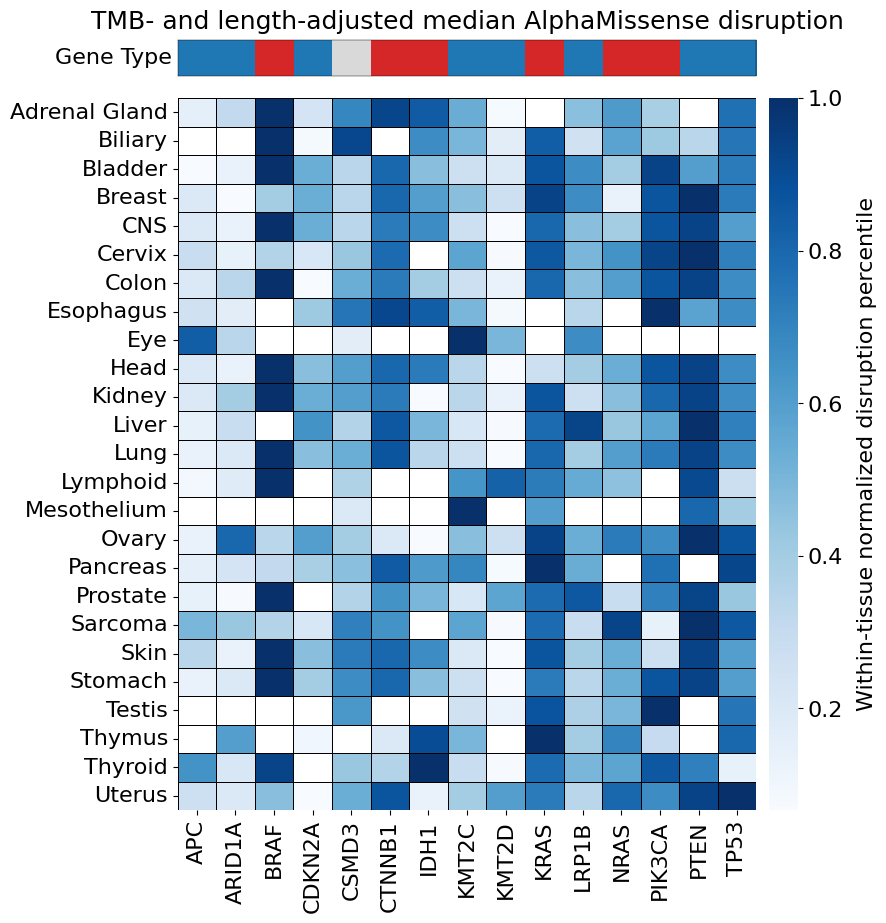

In [22]:
output_plot = OUTPUT_DIR / "tcga_alphamissense_median_length_tmb_adjusted_disruption_by_tissue_heatmap.png"
fig = plot_tissue_gene_heatmap(
    heatmap_df,
    "TMB- and length-adjusted median AlphaMissense disruption",
    output_plot,
)
print(output_plot)

### AlphaMissense tissues with complete AlphaGenome modality coverage

Keeping 13 tissue(s) with all selected AlphaGenome modalities.
/Users/an36943/PhD/Projects/cancer_non_coding/results/tcga_combined_disruption_heatmaps/tcga_alphamissense_complete_alphagenome_modalities_median_length_tmb_adjusted_disruption_by_tissue_heatmap.png


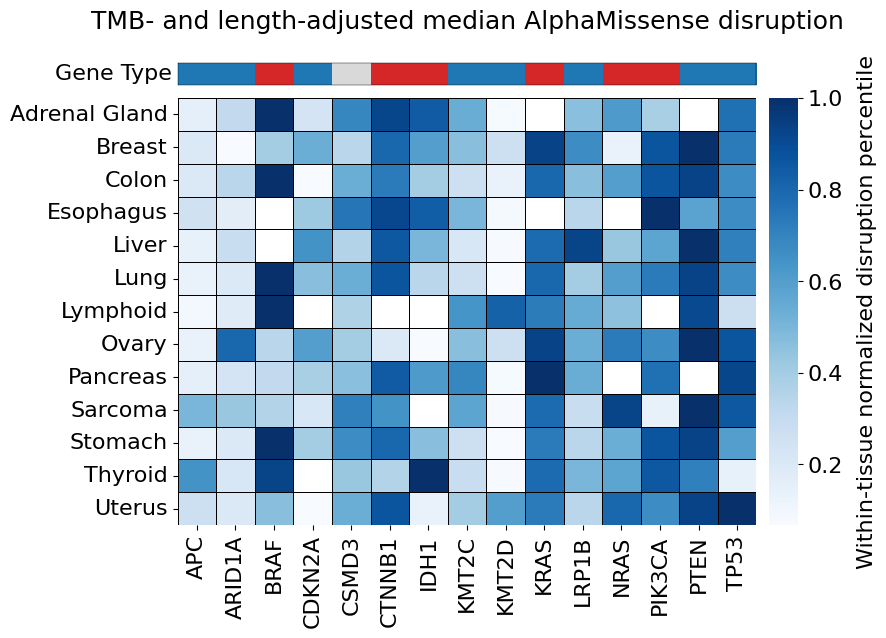

In [23]:
complete_alphamissense_heatmap_df = heatmap_df.loc[
    heatmap_df.index.intersection(complete_modality_tissues)
].copy()

output_plot = OUTPUT_DIR / "tcga_alphamissense_complete_alphagenome_modalities_median_length_tmb_adjusted_disruption_by_tissue_heatmap.png"
fig = plot_tissue_gene_heatmap(
    complete_alphamissense_heatmap_df,
    "TMB- and length-adjusted median AlphaMissense disruption",
    output_plot,
    tissue_order=complete_alphagenome_plot_tissue_order,
    gene_order=complete_alphagenome_plot_gene_order,
)
print(f"Keeping {complete_alphamissense_heatmap_df.shape[0]} tissue(s) with all selected AlphaGenome modalities.")
print(output_plot)

## Modality-specific plots

ATAC (16, 15)
/Users/an36943/PhD/Projects/cancer_non_coding/results/tcga_combined_disruption_heatmaps/tcga_ag_atac_median_length_tmb_adjusted_disruption_by_tissue_heatmap.png
CHIP_TF (17, 15)
/Users/an36943/PhD/Projects/cancer_non_coding/results/tcga_combined_disruption_heatmaps/tcga_ag_chip_tf_median_length_tmb_adjusted_disruption_by_tissue_heatmap.png
RNA_SEQ (25, 15)
/Users/an36943/PhD/Projects/cancer_non_coding/results/tcga_combined_disruption_heatmaps/tcga_ag_rna_seq_median_length_tmb_adjusted_disruption_by_tissue_heatmap.png
SPLICE_SITE_USAGE (25, 15)
/Users/an36943/PhD/Projects/cancer_non_coding/results/tcga_combined_disruption_heatmaps/tcga_ag_splice_site_usage_median_length_tmb_adjusted_disruption_by_tissue_heatmap.png


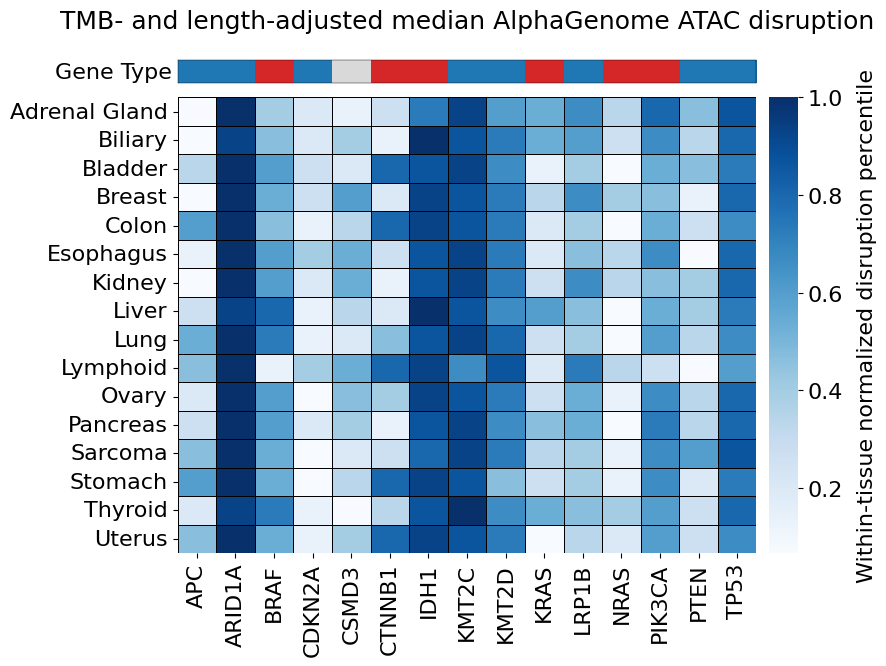

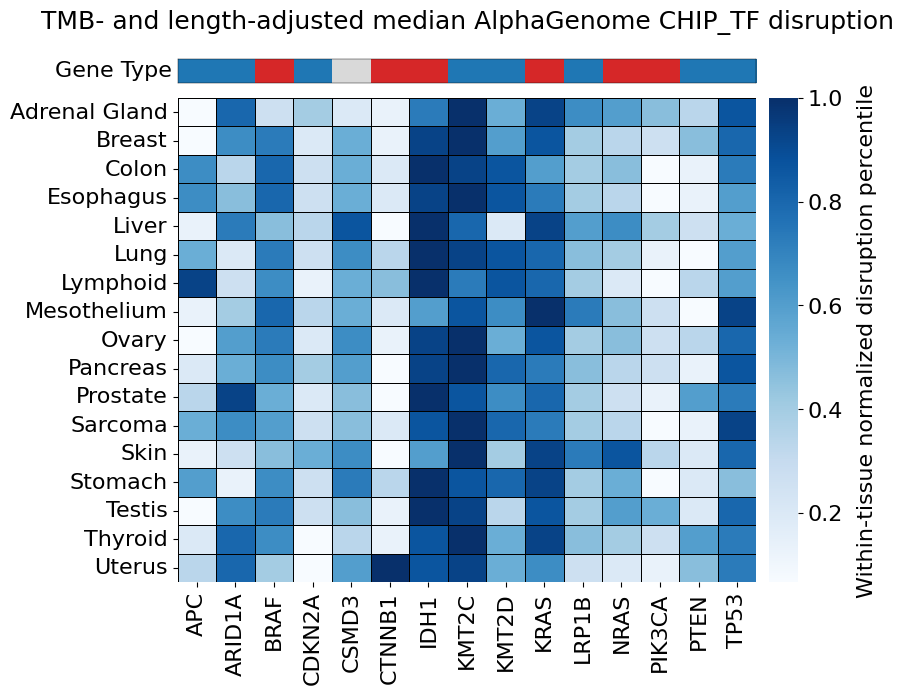

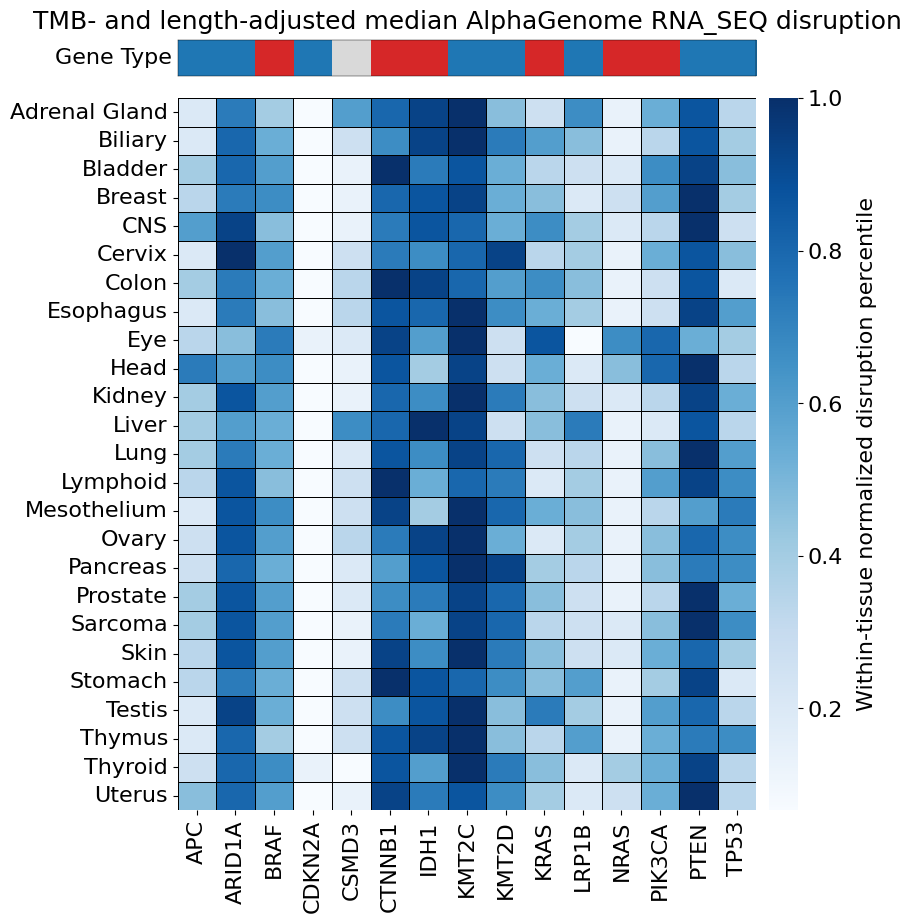

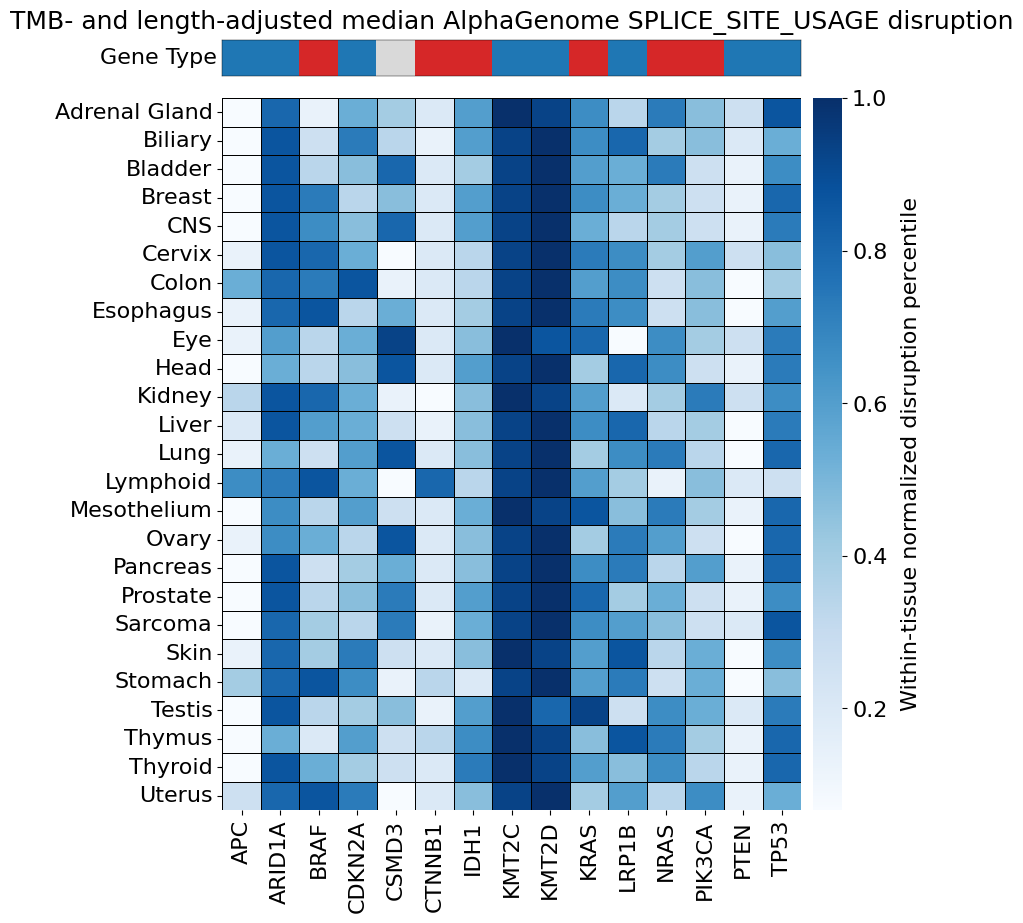

In [24]:
modalities = sorted(SELECTED_ALPHAGENOME_MODALITIES)
for modality in modalities:
    ag_mod_scores = alphagenome_modality_scores[alphagenome_modality_scores["output_type"].eq(modality)].copy()
    ag_mod_patient_gene_disruption, ag_mod_tissue_gene_disruption = summarize_disruption(
        ag_mod_scores,
        f"alphagenome_{modality.lower()}",
    )
    heatmap_df = ag_mod_tissue_gene_disruption.pivot_table(
        index="tissue",
        columns="gene",
        values="length_tmb_adjusted_disruption",
    )
    tissue_order = sorted(heatmap_df.index)
    gene_order = sorted(heatmap_df.columns)
    heatmap_df = heatmap_df.loc[tissue_order, gene_order]
    # Normalize the heatmap such that for each tissue, genes are ranked by percentile
    heatmap_df = heatmap_df.rank(pct=True, axis=1)
    print(modality, heatmap_df.shape)
    heatmap_df.head()

    output_plot = OUTPUT_DIR / f"tcga_ag_{modality.lower()}_median_length_tmb_adjusted_disruption_by_tissue_heatmap.png"
    fig = plot_tissue_gene_heatmap(
        heatmap_df,
        f"TMB- and length-adjusted median AlphaGenome {modality} disruption",
        output_plot,
    )
    print(output_plot)

## Tissue by modality aggregate disruption


In [25]:
# AlphaGenome values here reuse the shared modality-level preprocessing.
alphagenome_modality_patient_tissue = (
    alphagenome_modality_scores
    .groupby(["patient_id", "tissue", "output_type"], as_index=False)
    .agg(
        combined_gene_disruption=("normalized_score", "median"),
        tmb_adjusted_combined_gene_disruption=("normalized_score", "median"),
        length_tmb_adjusted_combined_gene_disruption=("normalized_score", "median"),
        n_genes=("gene", "nunique"),
        tmb=("tmb", "first"),
    )
)

alphamissense_modality_scores = (
    score_df[score_df["score_source"].eq("AlphaMissense")]
    .merge(cancer_tissue_map, on="cancer_type", how="left")
    .merge(tmb_df[["patient_id", "cancer_type", "tmb"]], on=["patient_id", "cancer_type"], how="left")
    .dropna(subset=["tissue", "normalized_score", "tmb"])
)
alphamissense_modality_scores["tmb_adjusted_disruption"] = (
    alphamissense_modality_scores["normalized_score"] / (alphamissense_modality_scores["tmb"] + TMB_PSEUDOCOUNT)
)
alphamissense_modality_scores = add_length_adjusted_residuals(
    alphamissense_modality_scores,
    value_col="tmb_adjusted_disruption",
    group_cols=["tissue", "output_type"],
    output_col="length_tmb_adjusted_disruption",
)
alphamissense_modality_patient_tissue = (
    alphamissense_modality_scores
    .groupby(["patient_id", "tissue", "output_type"], as_index=False)
    .agg(
        combined_gene_disruption=("normalized_score", "median"),
        tmb_adjusted_combined_gene_disruption=("tmb_adjusted_disruption", "median"),
        length_tmb_adjusted_combined_gene_disruption=("length_tmb_adjusted_disruption", "median"),
        n_genes=("gene", "nunique"),
        tmb=("tmb", "first"),
    )
)
modality_patient_tissue = pd.concat(
    [alphagenome_modality_patient_tissue, alphamissense_modality_patient_tissue],
    ignore_index=True,
)
modality_patient_tissue.head()


,patient_id,tissue,output_type,combined_gene_disruption,tmb_adjusted_combined_gene_disruption,length_tmb_adjusted_combined_gene_disruption,n_genes,tmb
0,TCGA-02-0016,CNS,RNA_SEQ,-0.268421,-0.268421,-0.268421,15,10.240210
1,TCGA-02-0016,CNS,SPLICE_SITE_USAGE,-0.126472,-0.126472,-0.126472,15,10.240210
2,TCGA-02-0026,CNS,RNA_SEQ,-0.731732,-0.731732,-0.731732,15,10.366561
3,TCGA-02-0026,CNS,SPLICE_SITE_USAGE,-0.624785,-0.624785,-0.624785,15,10.366561
4,TCGA-02-0033,CNS,RNA_SEQ,-0.145637,-0.145637,-0.145637,15,9.844958


In [26]:
tissue_modality_disruption = (
    modality_patient_tissue
    .groupby(["tissue", "output_type"], as_index=False)
    .agg(
        median_combined_gene_disruption=("combined_gene_disruption", "median"),
        median_tmb_adjusted_combined_gene_disruption=("tmb_adjusted_combined_gene_disruption", "median"),
        median_length_tmb_adjusted_combined_gene_disruption=("length_tmb_adjusted_combined_gene_disruption", "median"),
        n_patients=("patient_id", "nunique"),
        median_n_genes=("n_genes", "median"),
    )
)
tissue_modality_output = OUTPUT_DIR / "tcga_tissue_modality_median_length_tmb_adjusted_combined_gene_disruption.tsv"
tissue_modality_disruption.to_csv(tissue_modality_output, sep="\t", index=False)
tissue_modality_disruption.head()

,tissue,output_type,median_combined_gene_disruption,median_tmb_adjusted_combined_gene_disruption,median_length_tmb_adjusted_combined_gene_disruption,n_patients,median_n_genes
0,Adrenal Gland,ALPHAMISSENSE,-0.094129,-0.008770,0.008385,50,1.0
1,Adrenal Gland,ATAC,-0.358840,-0.358840,-0.358840,239,15.0
2,Adrenal Gland,CHIP_TF,-0.357474,-0.357474,-0.357474,239,15.0
3,Adrenal Gland,RNA_SEQ,-0.360926,-0.360926,-0.360926,239,15.0
4,Adrenal Gland,SPLICE_SITE_USAGE,-0.147089,-0.147089,-0.147089,239,15.0


In [27]:
tissue_modality_heatmap_df = tissue_modality_disruption.pivot_table(
    index="output_type",
    columns="tissue",
    values="median_length_tmb_adjusted_combined_gene_disruption",
)
modality_order = sorted(tissue_modality_heatmap_df.index)
tissue_modality_heatmap_df = tissue_modality_heatmap_df.loc[modality_order, sorted(tissue_modality_heatmap_df.columns)]

# Normalize each modality across tissues. Axes remain alphabetical.
tissue_modality_plot_df = tissue_modality_heatmap_df.rank(pct=True, axis=1)

tissue_modality_plot_df.head()


tissue,Adrenal Gland,Biliary,Bladder,Breast,CNS,Cervix,Colon,Esophagus,Eye,Head,...,Ovary,Pancreas,Prostate,Sarcoma,Skin,Stomach,Testis,Thymus,Thyroid,Uterus
output_type,,,,,,,,,,,,,,,,,,,,,
ALPHAMISSENSE,0.520000,0.5600,0.400,0.640000,0.12,0.68,0.280000,0.240000,0.04,0.44,...,0.6000,0.480000,0.760000,0.840000,0.800000,0.360000,0.920000,0.88,0.200000,0.080000
ATAC,0.187500,0.4375,0.375,0.812500,NaN,NaN,0.500000,0.937500,NaN,NaN,...,0.5625,0.125000,NaN,0.312500,NaN,0.625000,NaN,NaN,0.062500,0.875000
CHIP_TF,0.176471,NaN,NaN,0.647059,NaN,NaN,0.764706,0.529412,NaN,NaN,...,1.0000,0.411765,0.294118,0.117647,0.823529,0.882353,0.470588,NaN,0.058824,0.705882
RNA_SEQ,0.080000,0.1200,0.840,0.640000,0.60,0.80,0.280000,0.480000,1.00,0.76,...,0.2000,0.960000,0.240000,0.920000,0.680000,0.520000,0.360000,0.32,0.880000,0.160000
SPLICE_SITE_USAGE,0.680000,0.2000,0.920,0.440000,0.24,0.16,0.280000,0.080000,0.48,0.96,...,0.7600,0.640000,0.600000,0.720000,0.880000,0.320000,0.520000,0.80,0.400000,0.120000


/Users/an36943/PhD/Projects/cancer_non_coding/results/tcga_combined_disruption_heatmaps/tcga_tissue_modality_median_length_tmb_adjusted_combined_gene_disruption_heatmap.png


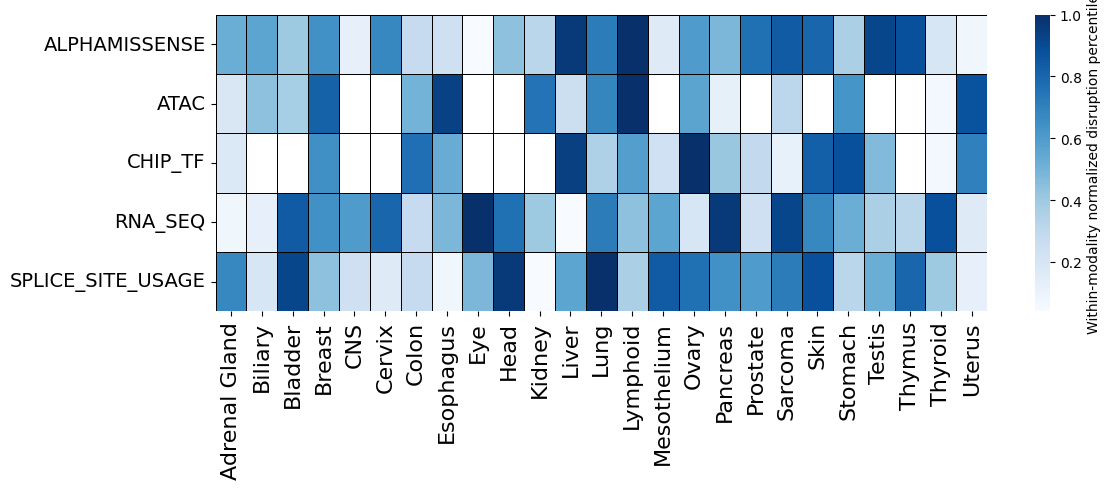

In [28]:
fig_width = max(12, 0.42 * tissue_modality_plot_df.shape[1])
fig_height = max(5, 0.55 * tissue_modality_plot_df.shape[0])
plt.figure(figsize=(fig_width, fig_height))
sns.heatmap(
    tissue_modality_plot_df,
    cmap="Blues",
    linewidths=0.5,
    linecolor="black",
    cbar_kws={"label": "Within-modality normalized disruption percentile"},
)
plt.xlabel("", fontsize=16)
plt.ylabel("", fontsize=16)
plt.xticks(rotation=90, ha="center", fontsize=16)
plt.yticks(rotation=0, fontsize=14)
plt.tight_layout()

tissue_modality_plot = OUTPUT_DIR / "tcga_tissue_modality_median_length_tmb_adjusted_combined_gene_disruption_heatmap.png"
plt.savefig(tissue_modality_plot, dpi=300, bbox_inches="tight")
print(tissue_modality_plot)

## Cancer type gene-by-modality disruption

/Users/an36943/PhD/Projects/cancer_non_coding/results/tcga_combined_disruption_heatmaps/tcga_brca_gene_by_modality_heatmap.png


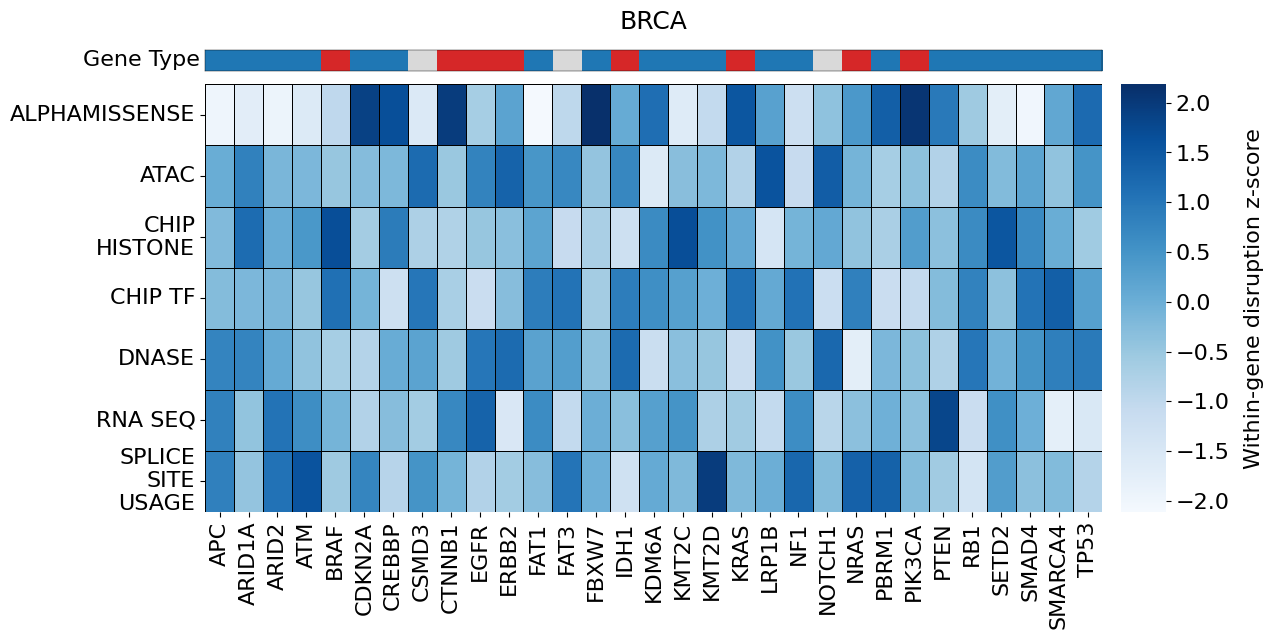

In [29]:
# Set the TCGA cancer type to visualize.
CANCER_TYPE = "BRCA"

plot_modalities = sorted(["ALPHAMISSENSE", *CANCER_TYPE_ALPHAGENOME_MODALITIES])
modality_labels = [
    fill(modality.replace("_", " "), width=8, break_long_words=False, break_on_hyphens=False)
    for modality in plot_modalities
]
# This plot intentionally uses every driver gene, rather than the top-N set used above.
cancer_driver_gene_lengths = pd.read_csv(GENE_COORDS, sep="\t", usecols=["gene", "length"]).drop_duplicates("gene")
cancer_driver_genes = set(cancer_driver_gene_lengths["gene"])

cancer_ag_scores = pd.read_csv(ALPHAGENOME_SCORES)
cancer_ag_scores = cancer_ag_scores[
    cancer_ag_scores["aggregation_type"].eq("L2_DIFF")
    & cancer_ag_scores["scorer"].eq("PATIENT_SINGLE_TRACK_SCORER")
    & ((cancer_ag_scores["track_strand"].eq(cancer_ag_scores["gene_strand"])) | cancer_ag_scores["track_strand"].eq("."))
    & cancer_ag_scores["cancer_type"].eq(CANCER_TYPE)
    & cancer_ag_scores["gene"].isin(cancer_driver_genes)
].groupby(["patient_id", "cancer_type", "gene", "output_type"], as_index=False).agg(score=("score", "median"))
cancer_ag_scores = cancer_ag_scores.merge(available_modalities, on=["cancer_type", "output_type"], how="inner")

cancer_zero_scores = (
    pd.read_csv(ALPHAGENOME_COMPLETION_LEDGER, sep="\t", dtype=str)
    .merge(patient_cancer, on="patient_id", how="inner")
    .query("cancer_type == @CANCER_TYPE")
    .loc[lambda df: df["gene"].isin(cancer_driver_genes)]
    .merge(available_modalities, on="cancer_type", how="inner")
    .assign(score=0.0)
)
cancer_ag_scores = pd.concat([cancer_ag_scores, cancer_zero_scores], ignore_index=True).drop_duplicates(
    ["patient_id", "cancer_type", "gene", "output_type"], keep="first"
)
cancer_ag_scores = cancer_ag_scores.merge(cancer_tissue_map, on="cancer_type", how="left").merge(
    tmb_df[["patient_id", "cancer_type", "tmb"]], on=["patient_id", "cancer_type"], how="left"
).dropna(subset=["tissue", "tmb", "score"])
cancer_ag_scores["tmb_adjusted_score"] = cancer_ag_scores["score"] / (cancer_ag_scores["tmb"] + TMB_PSEUDOCOUNT)
cancer_ag_scores = cancer_ag_scores.merge(
    cancer_driver_gene_lengths.rename(columns={"length": "gene_length"}), on="gene", how="left"
)
cancer_ag_scores["log10_gene_length"] = np.log10(cancer_ag_scores["gene_length"])
cancer_ag_scores["length_tmb_adjusted_score"] = np.nan
for _, group_idx in cancer_ag_scores.groupby(["patient_id", "tissue", "output_type"]).groups.items():
    valid_idx = cancer_ag_scores.loc[group_idx].index[
        cancer_ag_scores.loc[group_idx, "tmb_adjusted_score"].notna()
        & cancer_ag_scores.loc[group_idx, "log10_gene_length"].notna()
    ]
    if len(valid_idx) >= 2 and cancer_ag_scores.loc[valid_idx, "log10_gene_length"].nunique() >= 2:
        slope, intercept = np.polyfit(
            cancer_ag_scores.loc[valid_idx, "log10_gene_length"],
            cancer_ag_scores.loc[valid_idx, "tmb_adjusted_score"], deg=1,
        )
        cancer_ag_scores.loc[valid_idx, "length_tmb_adjusted_score"] = (
            cancer_ag_scores.loc[valid_idx, "tmb_adjusted_score"]
            - (slope * cancer_ag_scores.loc[valid_idx, "log10_gene_length"] + intercept)
        )
    elif len(valid_idx):
        cancer_ag_scores.loc[valid_idx, "length_tmb_adjusted_score"] = (
            cancer_ag_scores.loc[valid_idx, "tmb_adjusted_score"]
            - cancer_ag_scores.loc[valid_idx, "tmb_adjusted_score"].mean()
        )
cancer_ag_scores = cancer_ag_scores.dropna(subset=["length_tmb_adjusted_score"])
cancer_ag_scores["normalized_score"] = cancer_ag_scores.groupby("output_type")["length_tmb_adjusted_score"].transform(z_score_normalize)

cancer_am_scores = pd.read_csv(
    ALPHAMISSENSE_SCORES, sep="\t",
    usecols=["bcr_patient_barcode", "cancer_type", "gene", "combined_pathogenicity_burden"],
).rename(columns={"bcr_patient_barcode": "patient_id", "combined_pathogenicity_burden": "score"})
cancer_am_scores = cancer_am_scores[
    cancer_am_scores["cancer_type"].eq(CANCER_TYPE) & cancer_am_scores["gene"].isin(cancer_driver_genes)
].dropna(subset=["score"]).copy()
cancer_am_scores["output_type"] = "ALPHAMISSENSE"
cancer_am_scores["normalized_score"] = z_score_normalize(cancer_am_scores["score"])

cancer_modality_scores = pd.concat(
    [
        cancer_ag_scores[["patient_id", "cancer_type", "gene", "output_type", "normalized_score"]],
        cancer_am_scores[["patient_id", "cancer_type", "gene", "output_type", "normalized_score"]],
    ], ignore_index=True,
)

cancer_modality_heatmap_df = (
    cancer_modality_scores[cancer_modality_scores["cancer_type"].eq(CANCER_TYPE)]
    .groupby(["output_type", "gene"], as_index=False)
    .agg(median_normalized_disruption=("normalized_score", "median"))
    .pivot(index="output_type", columns="gene", values="median_normalized_disruption")
    .reindex(index=plot_modalities)
)
gene_order = sorted(cancer_driver_genes)
cancer_modality_heatmap_df = cancer_modality_heatmap_df.loc[:, gene_order]

# Z-score each gene across modalities for display.
gene_mean = cancer_modality_heatmap_df.mean(axis=0)
gene_std = cancer_modality_heatmap_df.std(axis=0)
cancer_modality_heatmap_df = cancer_modality_heatmap_df.sub(gene_mean, axis=1).div(gene_std.replace(0, np.nan), axis=1)

gene_types = [gene_type_by_gene.get(gene, "Unsure") for gene in cancer_modality_heatmap_df.columns]
type_colors = np.array([[mcolors.to_rgba(gene_type_colors[gene_type]) for gene_type in gene_types]])
fig_width = max(8, 0.4 * cancer_modality_heatmap_df.shape[1])
fig, axes = plt.subplots(
    2,
    2,
    figsize=(fig_width, 6),
    gridspec_kw={"height_ratios": [0.25, 5], "width_ratios": [20, 1], "hspace": 0.06, "wspace": 0.04},
)
type_ax, type_legend_ax = axes[0]
ax, cbar_ax = axes[1]
type_legend_ax.set_axis_off()
type_ax.imshow(type_colors, aspect="auto", extent=(0, cancer_modality_heatmap_df.shape[1], 0, 1))
type_ax.set_xlim(0, cancer_modality_heatmap_df.shape[1])
type_ax.set_xticks([])
type_ax.set_yticks([])
type_ax.set_ylabel("Gene Type", fontsize=16, rotation=0, ha="right", va="center")
for spine in type_ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.3)
sns.heatmap(
    cancer_modality_heatmap_df,
    cmap="Blues",
    center=0,
    linewidths=0.5,
    linecolor="black",
    cbar_ax=cbar_ax,
    cbar_kws={"label": "Within-gene disruption z-score"},
    ax=ax,
)
ax.set_title(CANCER_TYPE, fontsize=18, pad=40)
ax.set_xlabel("", fontsize=16)
ax.set_ylabel("", fontsize=16)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center", fontsize=16)
ax.set_yticklabels(modality_labels, rotation=0, fontsize=16)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=16)
cbar.set_label("Within-gene disruption z-score", fontsize=16, labelpad=10)
output_plot = OUTPUT_DIR / f"tcga_{CANCER_TYPE.lower()}_gene_by_modality_heatmap.png"
fig.savefig(output_plot, dpi=300, bbox_inches="tight")
print(output_plot)

## Cancer type gene-level modality profiles

/Users/an36943/PhD/Projects/cancer_non_coding/results/tcga_combined_disruption_heatmaps/tcga_brca_gene_modality_radar_plots.png


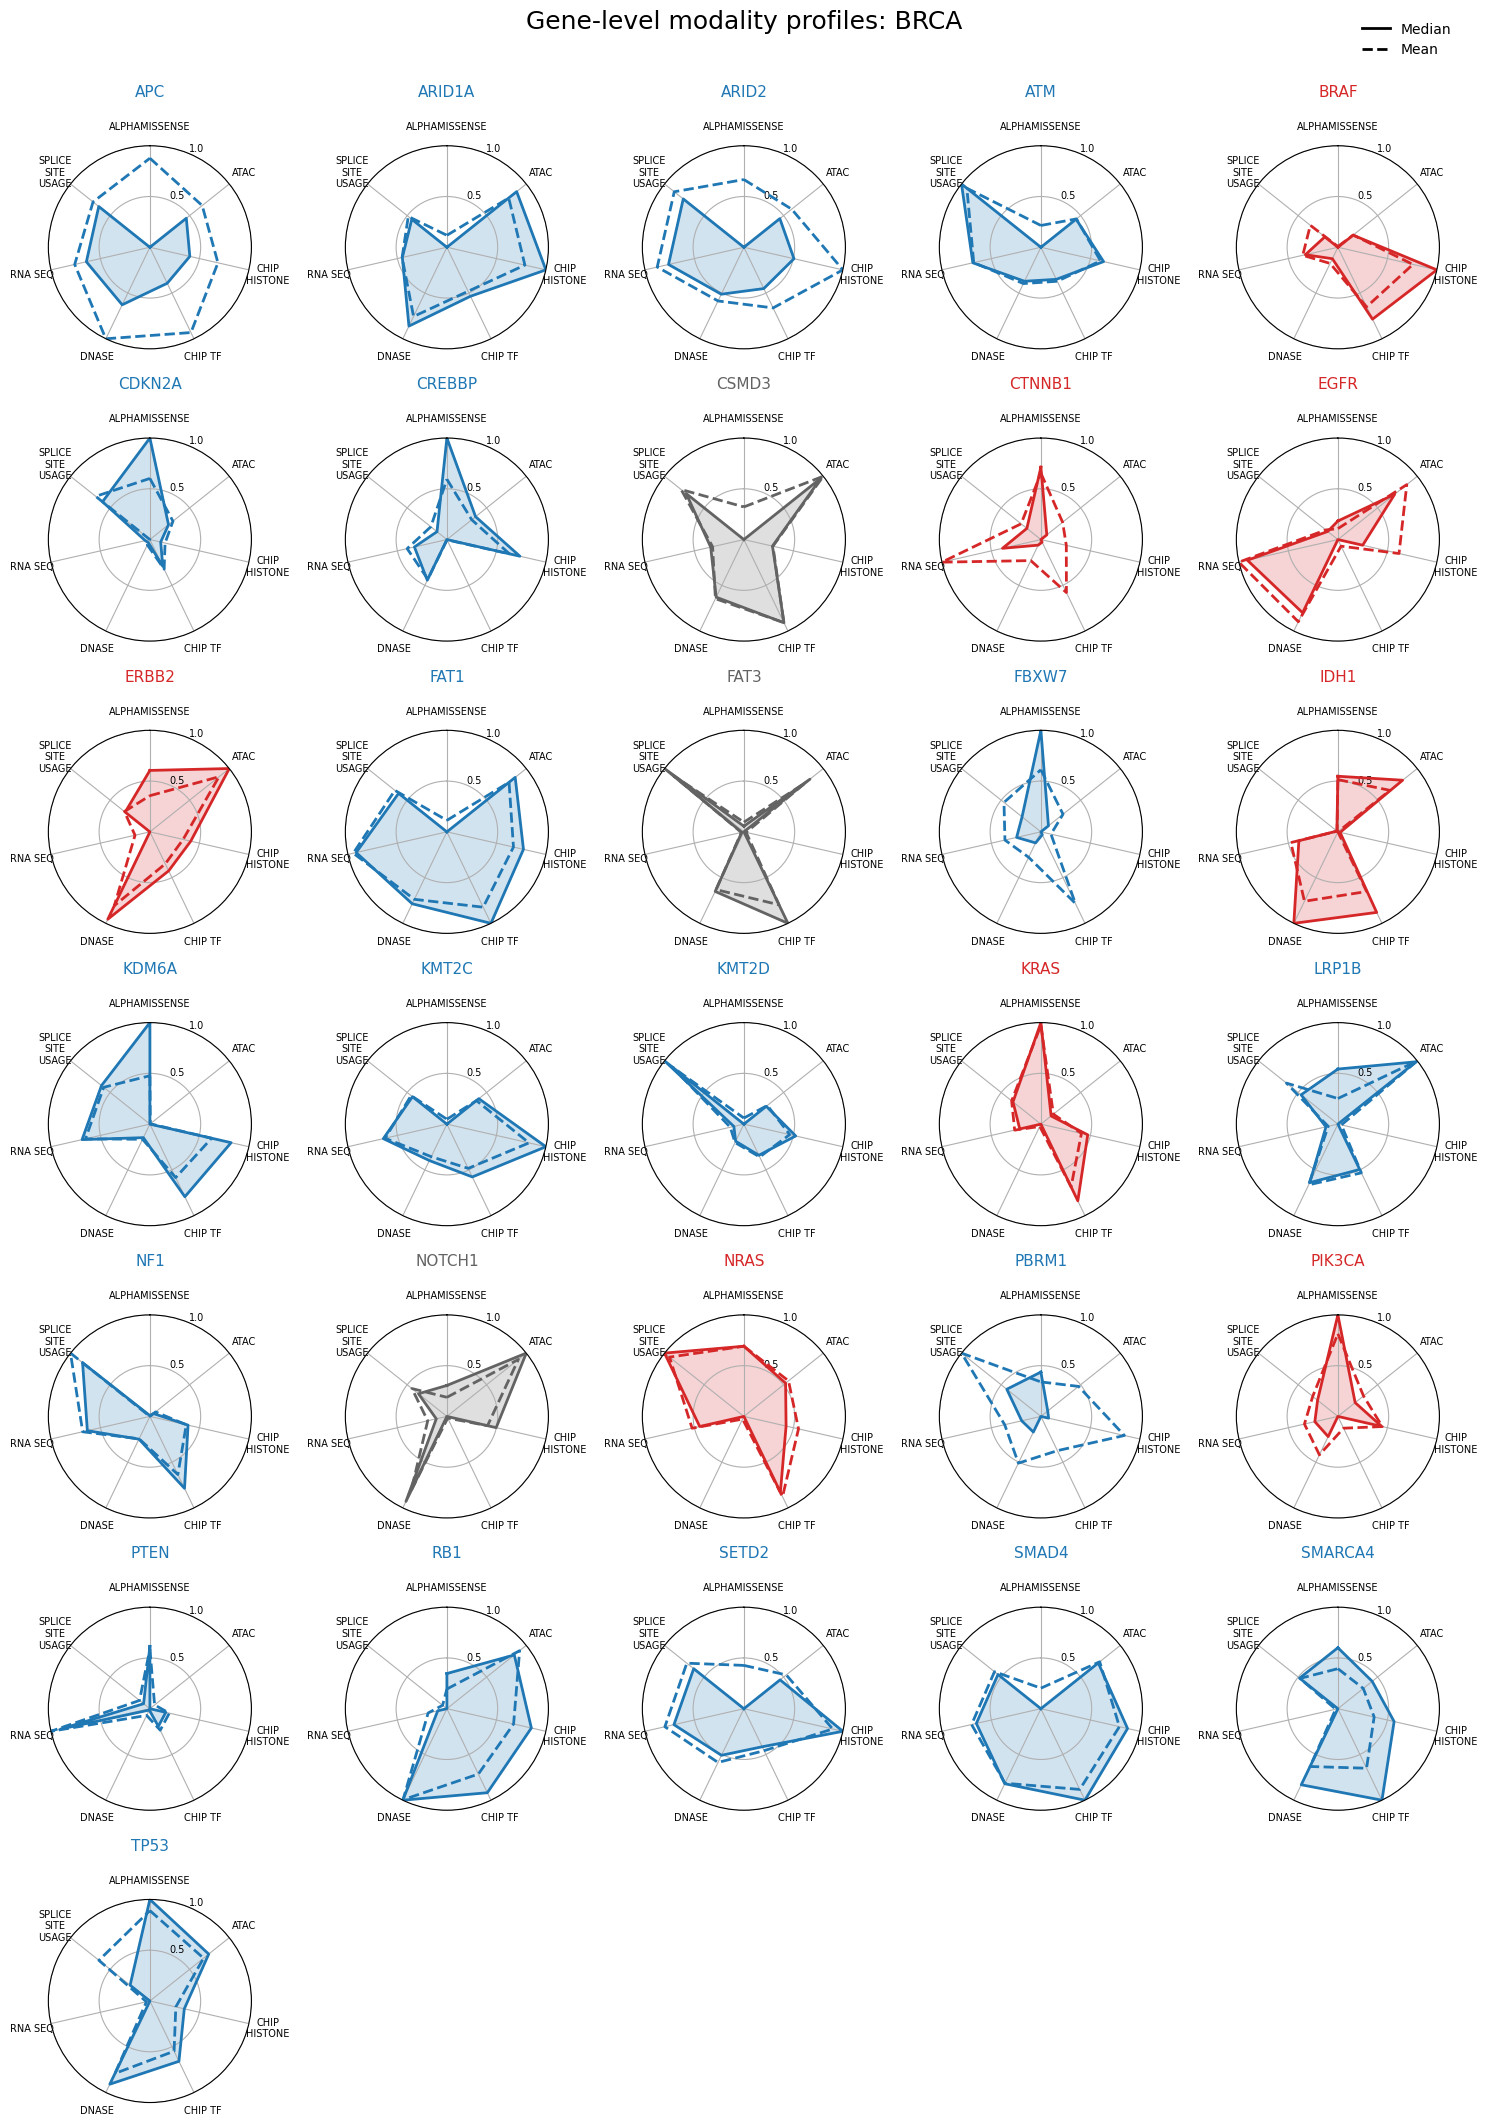

In [30]:
# Summarize each modality across patients using both the median and mean.
radial_summary = (
    cancer_modality_scores[cancer_modality_scores["cancer_type"].eq(CANCER_TYPE)]
    .groupby(["output_type", "gene"], as_index=False)
    .agg(
        median_normalized_disruption=("normalized_score", "median"),
        mean_normalized_disruption=("normalized_score", "mean"),
    )
)
radial_median_df = radial_summary.pivot(index="output_type", columns="gene", values="median_normalized_disruption").reindex(index=plot_modalities, columns=gene_order)
radial_mean_df = radial_summary.pivot(index="output_type", columns="gene", values="mean_normalized_disruption").reindex(index=plot_modalities, columns=gene_order)

# Radar plots require non-negative radii; use a shared 0-1 scale for each gene's median and mean profiles.
radial_values = pd.concat([radial_median_df, radial_mean_df], axis=0)
gene_min = radial_values.min(axis=0)
gene_range = radial_values.max(axis=0) - gene_min
radial_median_df = radial_median_df.sub(gene_min, axis=1).div(gene_range.replace(0, np.nan), axis=1)
radial_mean_df = radial_mean_df.sub(gene_min, axis=1).div(gene_range.replace(0, np.nan), axis=1)

n_modalities = len(plot_modalities)
angles = np.linspace(0, 2 * np.pi, n_modalities, endpoint=False)
angles = np.r_[angles, angles[0]]
genes = gene_order
radial_gene_type_colors = {**gene_type_colors, "Unsure": "#636363"}
n_cols = 5
n_rows = int(np.ceil(len(genes) / n_cols))
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(3 * n_cols, 3 * n_rows),
    subplot_kw={"projection": "polar"},
)

for ax, gene in zip(axes.flat, genes):
    median_values = radial_median_df[gene].fillna(0).to_numpy()
    mean_values = radial_mean_df[gene].fillna(0).to_numpy()
    median_values = np.r_[median_values, median_values[0]]
    mean_values = np.r_[mean_values, mean_values[0]]
    gene_type = gene_type_by_gene.get(gene, "Unsure")
    color = radial_gene_type_colors[gene_type]
    ax.plot(angles, median_values, color=color, linewidth=2)
    ax.fill(angles, median_values, color=color, alpha=0.2)
    ax.plot(angles, mean_values, color=color, linewidth=2, linestyle="--")
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(modality_labels, fontsize=7)
    ax.set_yticks([0.5, 1.0])
    ax.set_yticklabels(["0.5", "1.0"], fontsize=7)
    ax.set_ylim(0, 1)
    ax.set_title(gene, color=color, fontsize=11, pad=18)

for ax in axes.flat[len(genes):]:
    ax.set_axis_off()

fig.suptitle(f"Gene-level modality profiles: {CANCER_TYPE}", fontsize=18, y=1.01)
fig.legend(
    handles=[
        Line2D([0], [0], color="black", linewidth=2, label="Median"),
        Line2D([0], [0], color="black", linewidth=2, linestyle="--", label="Mean"),
    ],
    loc="upper right",
    bbox_to_anchor=(0.98, 1.01),
    frameon=False,
)
fig.tight_layout()
output_plot = OUTPUT_DIR / f"tcga_{CANCER_TYPE.lower()}_gene_modality_radar_plots.png"
fig.savefig(output_plot, dpi=300, bbox_inches="tight")
print(output_plot)

## Pan-cancer gene-level modality profiles

/Users/an36943/PhD/Projects/cancer_non_coding/results/tcga_combined_disruption_heatmaps/tcga_pancancer_gene_modality_radar_plots.png


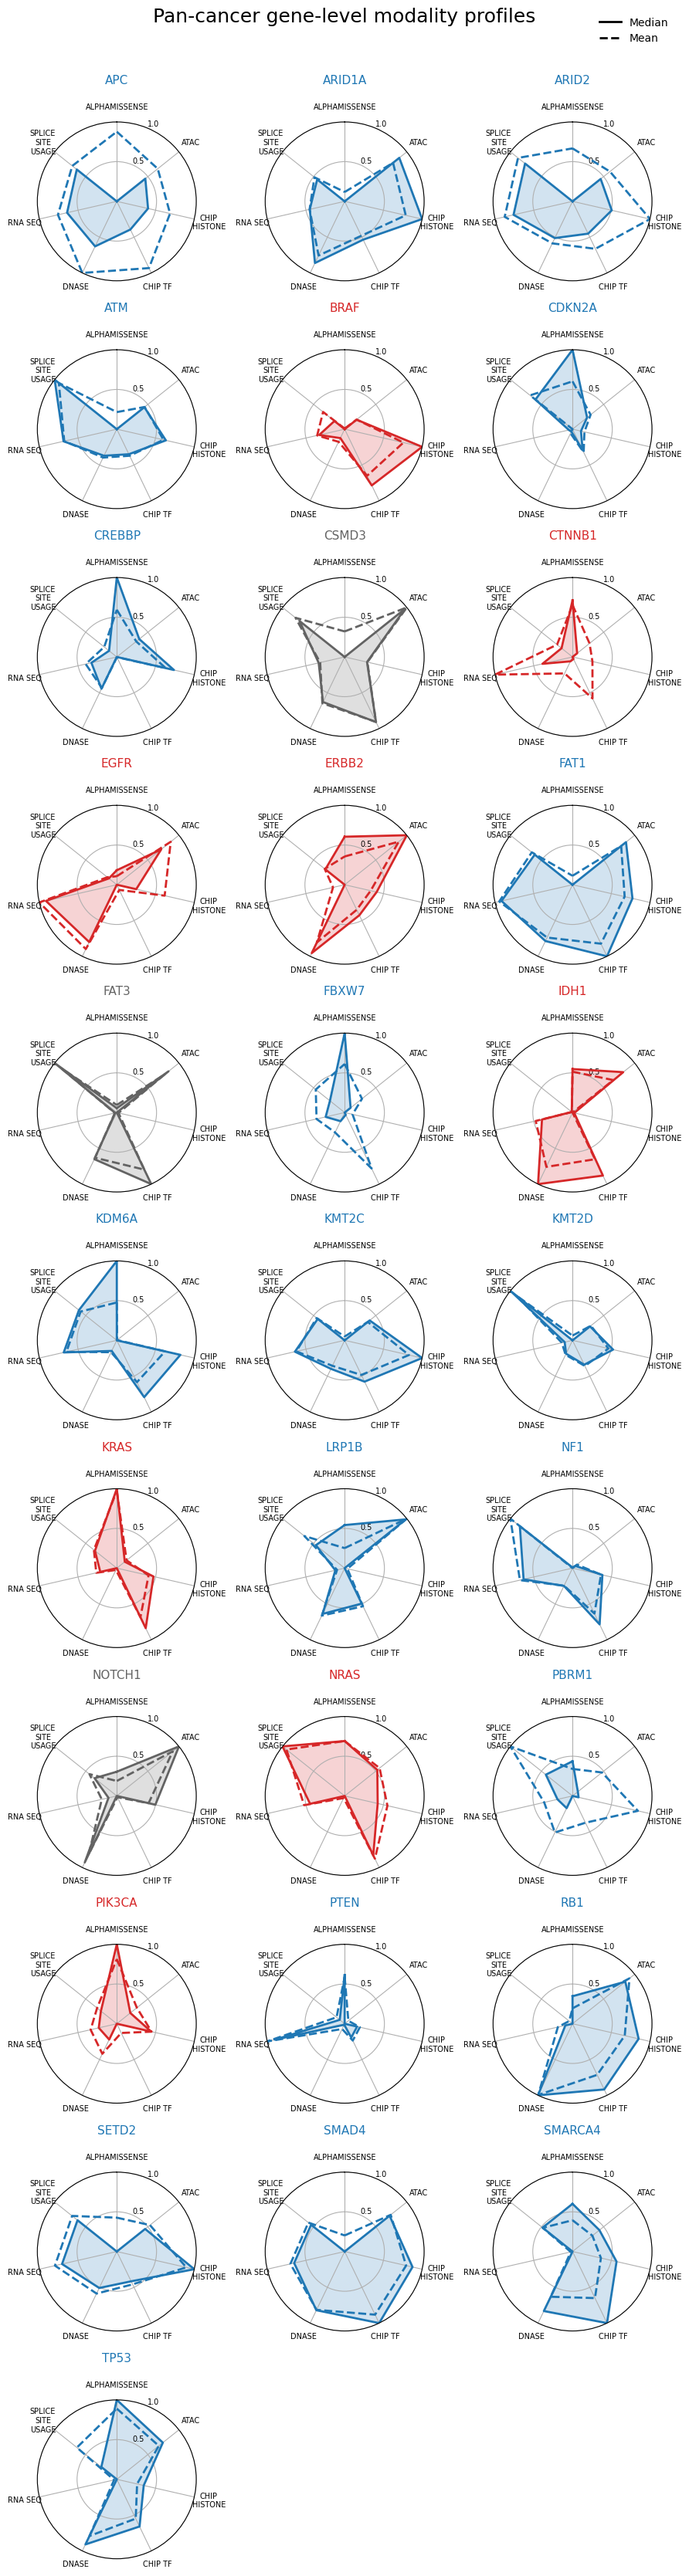

In [31]:
# Summarize each modality across all cancer types using both the median and mean.
pancancer_radial_summary = (
    cancer_modality_scores
    .groupby(["output_type", "gene"], as_index=False)
    .agg(
        median_normalized_disruption=("normalized_score", "median"),
        mean_normalized_disruption=("normalized_score", "mean"),
    )
)
pancancer_gene_order = sorted(pancancer_radial_summary["gene"].unique())
pancancer_median_df = (
    pancancer_radial_summary
    .pivot(index="output_type", columns="gene", values="median_normalized_disruption")
    .reindex(index=plot_modalities, columns=pancancer_gene_order)
)
pancancer_mean_df = (
    pancancer_radial_summary
    .pivot(index="output_type", columns="gene", values="mean_normalized_disruption")
    .reindex(index=plot_modalities, columns=pancancer_gene_order)
)

# Use a shared 0-1 scale for each gene's pan-cancer median and mean profiles.
pancancer_values = pd.concat([pancancer_median_df, pancancer_mean_df], axis=0)
pancancer_gene_min = pancancer_values.min(axis=0)
pancancer_gene_range = pancancer_values.max(axis=0) - pancancer_gene_min
pancancer_median_df = pancancer_median_df.sub(pancancer_gene_min, axis=1).div(pancancer_gene_range.replace(0, np.nan), axis=1)
pancancer_mean_df = pancancer_mean_df.sub(pancancer_gene_min, axis=1).div(pancancer_gene_range.replace(0, np.nan), axis=1)

pancancer_genes = pancancer_gene_order
radial_gene_type_colors = {**gene_type_colors, "Unsure": "#636363"}
n_cols = 3
n_rows = int(np.ceil(len(pancancer_genes) / n_cols))
fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows),
    subplot_kw={"projection": "polar"},
)

for ax, gene in zip(axes.flat, pancancer_genes):
    median_values = pancancer_median_df[gene].fillna(0).to_numpy()
    mean_values = pancancer_mean_df[gene].fillna(0).to_numpy()
    median_values = np.r_[median_values, median_values[0]]
    mean_values = np.r_[mean_values, mean_values[0]]
    gene_type = gene_type_by_gene.get(gene, "Unsure")
    color = radial_gene_type_colors[gene_type]
    ax.plot(angles, median_values, color=color, linewidth=2)
    ax.fill(angles, median_values, color=color, alpha=0.2)
    ax.plot(angles, mean_values, color=color, linewidth=2, linestyle="--")
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(modality_labels, fontsize=7)
    ax.set_yticks([0.5, 1.0])
    ax.set_yticklabels(["0.5", "1.0"], fontsize=7)
    ax.set_ylim(0, 1)
    ax.set_title(gene, color=color, fontsize=11, pad=18)

for ax in axes.flat[len(pancancer_genes):]:
    ax.set_axis_off()

fig.suptitle("Pan-cancer gene-level modality profiles", fontsize=18, y=1.01)
fig.legend(
    handles=[
        Line2D([0], [0], color="black", linewidth=2, label="Median"),
        Line2D([0], [0], color="black", linewidth=2, linestyle="--", label="Mean"),
    ],
    loc="upper right", bbox_to_anchor=(0.98, 1.01), frameon=False,
)
fig.tight_layout()
output_plot = OUTPUT_DIR / "tcga_pancancer_gene_modality_radar_plots.png"
fig.savefig(output_plot, dpi=300, bbox_inches="tight")
print(output_plot)